# Proyek Analisis Data: [Bike Sharing Dataset (Day)]
- **Nama:** [Rieftian Havil Syawalludy]
- **Email:** [cdcc006d6y2525@student.devacademy.id]
- **ID Dicoding:** [CDCC006D6Y2525]

## Menentukan Pertanyaan Bisnis

- Bagaimana faktor waktu berpengaruh terhadap jumlah pengguna penyewaan sepeda?
- Bagaimana kondisi cuaca berpengaruh terhadap jumlah pengguna penyewaan sepeda?
- Bagaimana perbedaan perilaku antara pengguna casual dan registered?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## Data Wrangling

### Gathering Data

In [ ]:
# Load dataset
file_id = '1J63FnKiW5Nk0FEU4_FLy4GHEy_DDcCA4'
url = f'https://drive.google.com/uc?export=download&id={file_id}'
df = pd.read_csv(url)
df.head()


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,1/1/2011,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,1/2/2011,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,1/3/2011,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,1/4/2011,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,1/5/2011,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Terdapat 16 kolom berbeda yang masing - masing memiliki informasi menarik dan dapat digunakan nantinya sesuai kebutuhan analisis.
- Variabel target (Y) dalam dataset ini adalah cnt yang dapat diturunkan menjadi kombinasi dua variabel lain yaitu casual dan registered. Sedangkan variabel lainnya bisa digunakan menjadi faktor (X).
- Variabel temp, stemp, hum, dan windspeed sudah dalam kondisi normalisasi.
- Variabel season, yr, mnthm, holiday, weekday, workingday, dan weathersit sudah dilakukan proses encoding.

### Assessing Data

In [ ]:
# Melihat keseluruhan dataset
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**
- Terdapat 731 baris untuk semua kolom pada dataset.
- Terdapat kesalahan tipe data pada kolom dteday yang seharusnya 'datetime' bukan 'object'
- Tidak terdapat keanehan atau kesalahan input pada kolom numerik.

In [ ]:
# Melihat missing value dataset
df.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


**Insight:**
- Tidak ada missing value pada semua kolom.

In [ ]:
# Melihat data duplikat
df.duplicated().sum()

np.int64(0)

**Insight:**
- Tidak ada data duplikat dalam dataset.

### Cleaning Data

In [ ]:
# Mengubah tipe data kolom dteday
df['dteday'] = pd.to_datetime(df['dteday'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

**Insight:**
- Berhasil mengubah tipe data kolom dteday dari 'object' menjadi 'datetime'

## Exploratory Data Analysis (EDA)

### Explore Dataset

In [ ]:
# Statistik deskriptif
display(df.describe(include="all"))



,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


**Insight:**
- Rata - rata terdapat sekitar 4504 penyewaan sepeda setiap harinya, dengan didominasi oleh pengguna terregistrasi sekitar 3656 atau 81% pengguna dan 19% sisanya oleh pengguna casual.
- Terdapat rentang yang jauh antara nilai minimum dan maximum banyaknya sepeda yang disewakan dalam satu hari yaitu 22 dibandingkan dengan 8714 yang menandakan ada suatu hal yang mempengaruhinya secara ekstrim dan penyebaran yang tinggi.
- Rata - rata suhu (temp) sebesar 0.49 mengindikasikan lingkungan sehari - hari tidak terlalu dingin ataupun panas sehingga cukup ideal untuk bersepeda.
- Rata - rata kelembaban (hum) lumayan tinggi sebesar 0.62
- Rata - rata kecepatan angin (windspeed) 0.19 artinya kondisi angin tidak terlalu ekstrim.

In [ ]:
# Melihat sebaran cuaca
df['weathersit'].value_counts()

,count
weathersit,
1,463
2,247
3,21


**Insight:**
- Dari 731 hari pengamatan, sebagian besar yaitu sebanyak 463 hari itu cuacanya cerah atau sedikit berawan, kemudian 247 hari itu cuacannya berkabut atau berawan, dan 21 hari sisanya itu hujan ringan atau turun salju ringan. Tidak tercatat adanya cuaca yang sangat buruk seperti hujan lebat atau turun salju ekstrim.

In [ ]:
# Melihat sebaran musim
df['season'].value_counts()

,count
season,
3,188
2,184
1,181
4,178


**Insight:**
- Dari 731 hari pengamatan, pembagian hari setiap musim cukup seimbang dan tidak berbeda jauh. Musim gugur dengan jumlah hari terbanyak dengan musim dingin yang paling sedikit hanya terpaut 10 hari.

In [ ]:
# Melihat sebaran bulan
df['mnth'].value_counts()

,count
mnth,
1,62
3,62
7,62
5,62
12,62
10,62
8,62
4,60
9,60


**Insight:**
- Dari 731 hari, jumlah hari tiap bulan seimbang dan sesuai karena memang data diambil setiap hari.

In [ ]:
# Melihat sebaran hari
print(df['weekday'].value_counts())
print('='*50)

print(df['workingday'].value_counts())
print('='*50)

print(df['holiday'].value_counts())

weekday
6    105
0    105
1    105
2    104
3    104
4    104
5    104
Name: count, dtype: int64
workingday
1    500
0    231
Name: count, dtype: int64
holiday
0    710
1     21
Name: count, dtype: int64


**Insight:**
- Dari 731 hari, sebaran weekday tentu merata karena data diambil secara urut setiap harinya dengan 500 hari pada hari kerja dan 231 hari pada hari tidak bekerja ataupun hari libur nasional. Hari libur nasional dalam 731 hari tercatat sebanyak 21 hari.

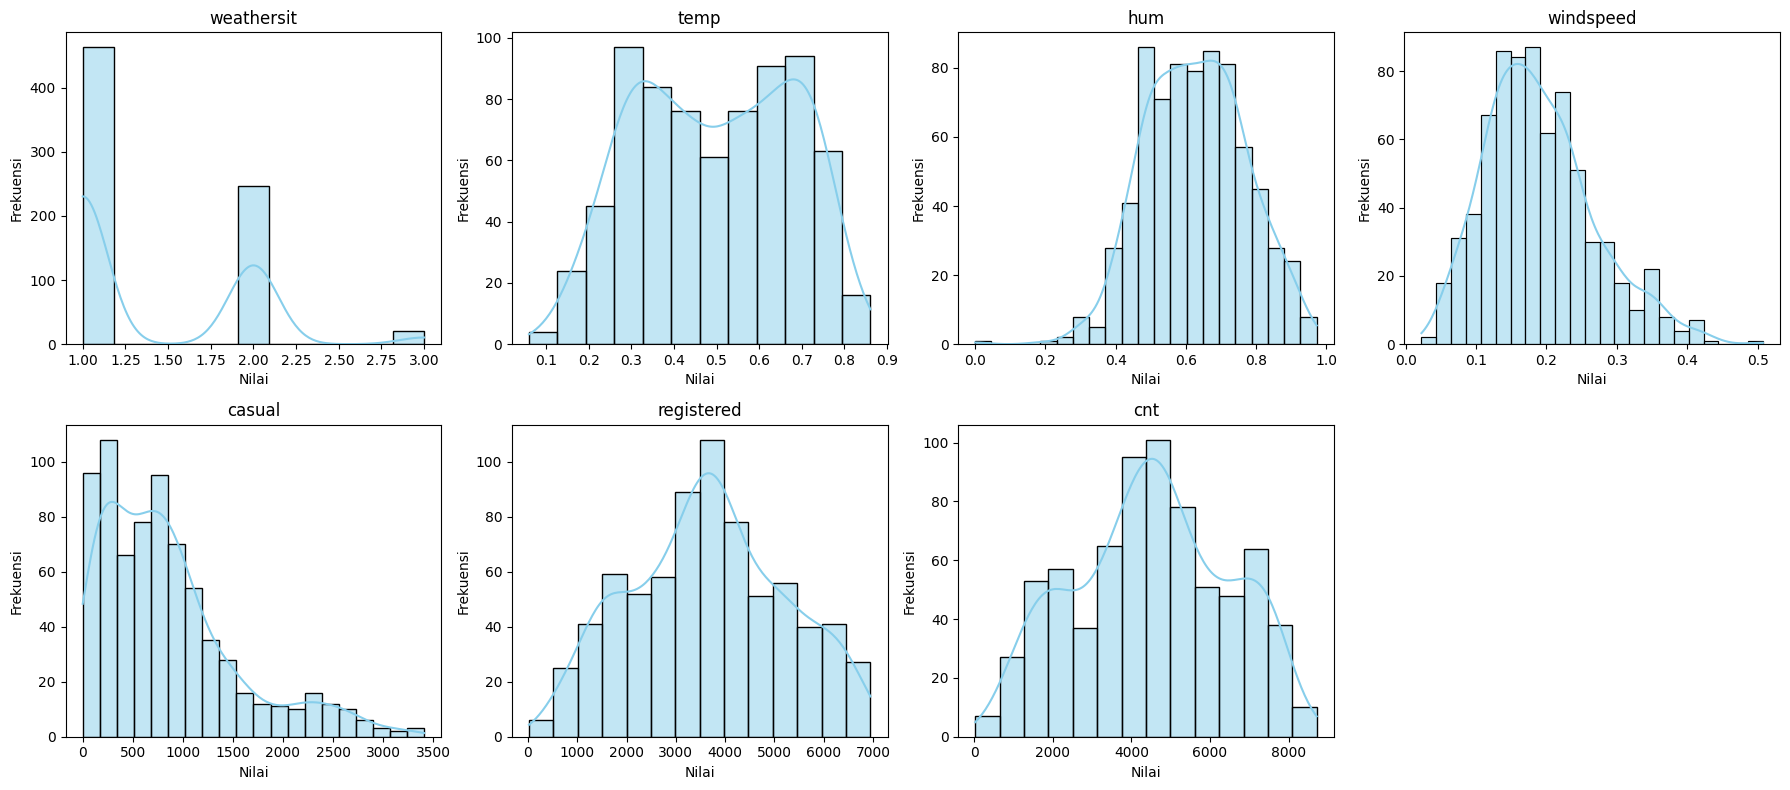

In [ ]:
# Histogram sebaran variabel
col = ['weathersit','temp','hum','windspeed','casual','registered','cnt']


fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, column in enumerate(col):
    sns.histplot(df[column], bins='auto', kde=True, color='skyblue', ax= axes[i])

    axes[i].set_title(column)
    axes[i].set_xlabel("Nilai")
    axes[i].set_ylabel("Frekuensi")
fig.delaxes(axes[7])
plt.tight_layout()
plt.show()

**Insight:**
- Terlihat sebaran cuaca (weathersit) miring ke kanan atau _right-skewed_ yang menandakan memang didominasi cuaca cerah atau sedikit berawan.
- Sebaran suhu (temp) mengindikasikan tidak ada zona suhu dominan dan terlihat bahwa data sangat tersebar.
- Sebaran kelembapan (hum) cenderung miring ke kiri walaupun hanya sedikit yang menandakan lingkungan sehari - hari memang memiliki kelembapan yang cukup tinggi.
- Sebaran kecepatan angin (windspeed) cenderung miring ke kanan walaupun hanya sedikit yang menandakan lingkungan sehari - hari memang memiliki kecepatan angin yang kecil.
- Sebaran pengguna casual terlihat miring ke kanan yang mengindikasikan bahwa pengguna casual lebih banyak nilai rendahnya dan seringkali tidak konsisten karena hanya pada kondisi tertentu permintaan menyewa sepeda tinggi.
- Sebaran pengguna registered lebih simetris dan terpusat ditengah yang mengindikasikan bahwa pengguna relatif lebih stabil dan rutin dalam menyewa sepeda.
- Sebaran total pengguna (cnt) dapat dikatakan kombinasi keduanya yaitu cukup simetris ditengah walaupun memiliki kecenderungan miring ke kanan yang disebabkan pengguna casual. Tetapi, secara keseluruhan total pengguna tetap stabil.

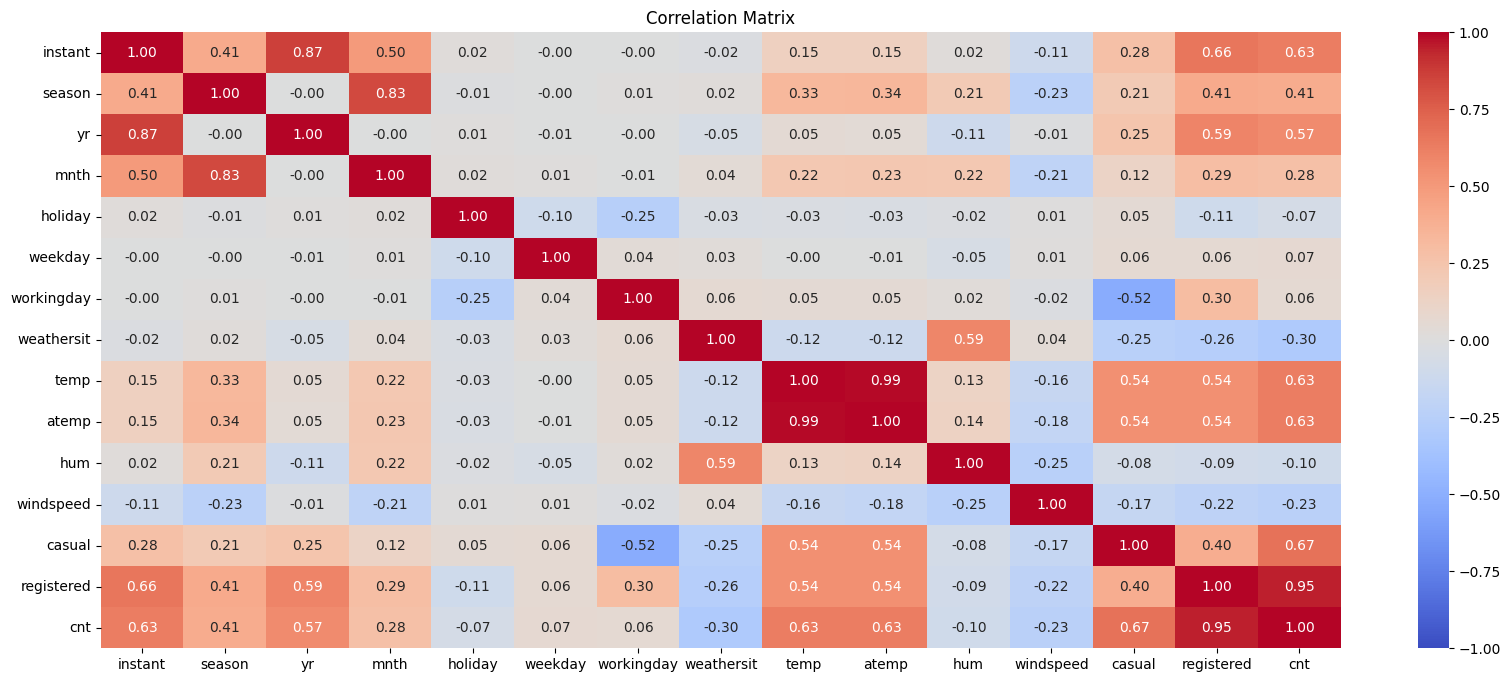

In [ ]:
# Membuat visualisasi heatmap
numerical_cols = df.select_dtypes(include=['number']).columns


correlation = df[numerical_cols].corr()

plt.figure(figsize=(20, 8))
sns.heatmap(correlation,
               annot=True,
               cmap='coolwarm',
               fmt=".2f",
               vmin=-1,
               vmax=1)
plt.xticks(rotation=0)
plt.title('Correlation Matrix')
plt.show()

**Insight:**
- Terdapat korelasi atau hubungan positif yang cukup kuat antara temperatur atau suhu terhadap total pengguna harian, yang artinya dapat dikatakan bahwa ketika suhu naik maka total pengguna harian juga naik.
- Terdapat hubungan yang cukup antara musim dengan total pengguna harian, yang artinya musim memiliki dampak terhadap pengguna harian.
- Terdapat hubungan negatif walaupun lemah antara kecepatan angin dengan total  pengguna harian, yang artinya dapat dikatakan bahwa semakin tinggi kecepatan angin maka semakin sedikit total pengguna harian.
- Dengan koefisien korelasi 0.95 yang berarti berpengaruh kuat terhadap total pengguna harian dibandingkan 0.67 yang pengaruhnya cukup kuat juga walaupun tetap ada jarak pembeda. Hal ini mengindikasikan bahwa pengguna registered lebih berpengaruh terhadap total pengguna dibandingkan pengguna casual.
- Hal menarik lainnya adalah terdapat perbedaan tanda koefisien korelasi pada pengguna casual dan registered terhadap hari kerja (workingday). Pada pelanggan casual terdapat hubungan negatif yang cukup dengan working days, yang artinya jika bukan hari kerja (liburan atau akhir pekan) maka pengguna harian casual cenderung meningkat. Sedangkan pengguna registered terdapat hubungan positif yang lemah yang mengindikasikan bahwa pengguna harian registered cenderung meningkat di hari kerja walaupun pengaruhnya lemah.

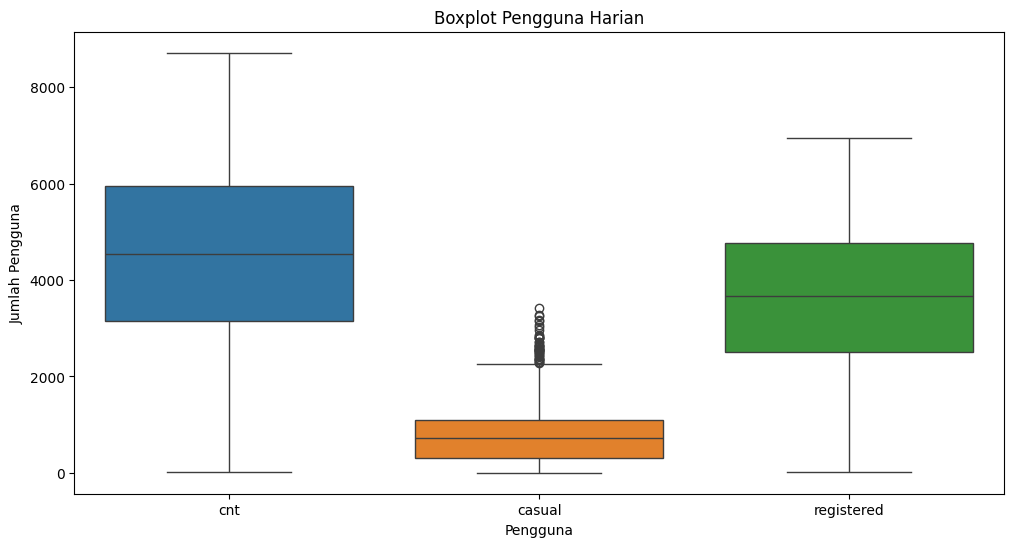

In [ ]:
# Membuat boxplot
user = ['cnt','casual','registered']
plt.figure(figsize=(12, 6))
sns.boxplot(df[user])
plt.title("Boxplot Pengguna Harian")
plt.xlabel("Pengguna")
plt.ylabel("Jumlah Pengguna")
plt.show()

**Insight:**
- Tidak terdapat pencilan atau _outlier_ pada total pengguna dan pengguna registered, akan tetapi terlihat cukup banyak pencilan pada pengguna casual yang mengindikasikan kelompok ini memiliki perilaku yang lebih tidak stabil dan kemungkinan besar dipengaruhi oleh faktor waktu atau lingkungan.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana faktor waktu berpengaruh terhadap jumlah pengguna penyewaan sepeda?


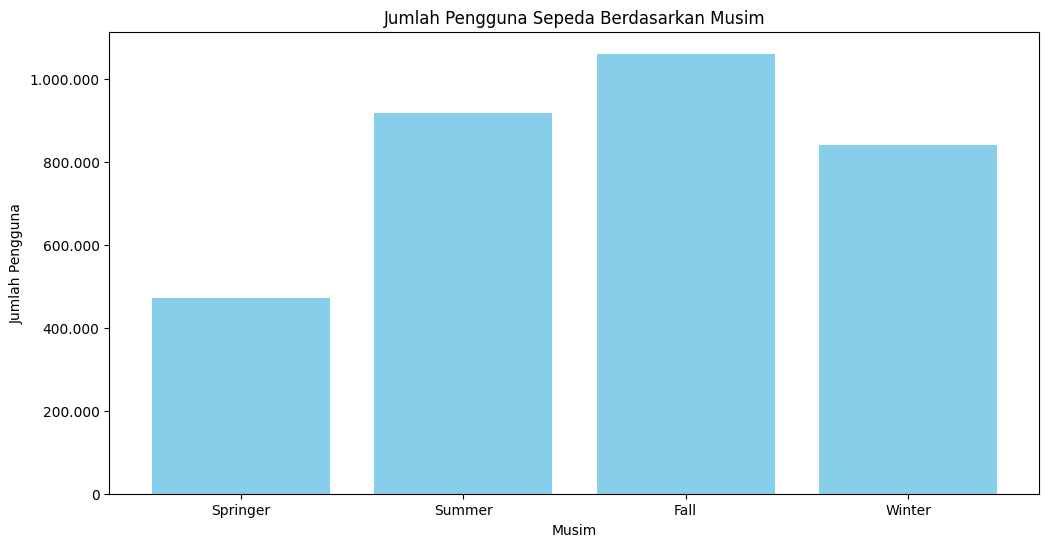



Tabel Jumlah Pengguna Berdasarkan Musim
     season      sum         mean
0  Springer   471348  2604.132597
1    Summer   918589  4992.331522
2      Fall  1061129  5644.303191
3    Winter   841613  4728.162921


In [ ]:
# Menampilkan sebaran pengguna berdasarkan musim

total_per_musim = df.groupby('season')['cnt'].sum().reset_index()


plt.figure(figsize=(12, 6))
positions = range(len(total_per_musim))

plt.bar(total_per_musim['season'],total_per_musim['cnt'], color = 'skyblue')

plt.title('Jumlah Pengguna Sepeda Berdasarkan Musim')
plt.xlabel('Musim')
plt.ylabel('Jumlah Pengguna')

label_season = {1:'Springer', 2:'Summer', 3:'Fall', 4:'Winter'}
plt.xticks(ticks = total_per_musim['season'], labels = [label_season[i] for i in total_per_musim['season']])
formatter = plt.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.'))
plt.gca().yaxis.set_major_formatter(formatter)
plt.show()

print("\n")
print("="*137)
print("Tabel Jumlah Pengguna Berdasarkan Musim")
print("="*137)

tabel_per_musim = df.groupby('season')['cnt'].agg(['sum','mean']).reset_index()
tabel_per_musim['season']=['Springer','Summer','Fall','Winter']
print(tabel_per_musim)
print("="*137)

**Insight:**
- Total pengguna menyewa sepeda paling banyak pada musim gugur (_fall_ ) yang kemudian diikuti oleh musim panas (_summer_ ), lalu diikuti oleh musim dingin (_winter_ ), dan di posisi terakhir adalah musim semi (_springer_ ).
- Rata - rata harian total pengguna pada musim semi adalah sekitar 2604.
- Rata - rata harian total pengguna pada musim panas adalah sekitar 4992.
- Rata - rata harian total pengguna pada musim gugur adalah sekitar 5644.
- Rata - rata harian total pengguna pada musim dingin adalah sekitar 4728.

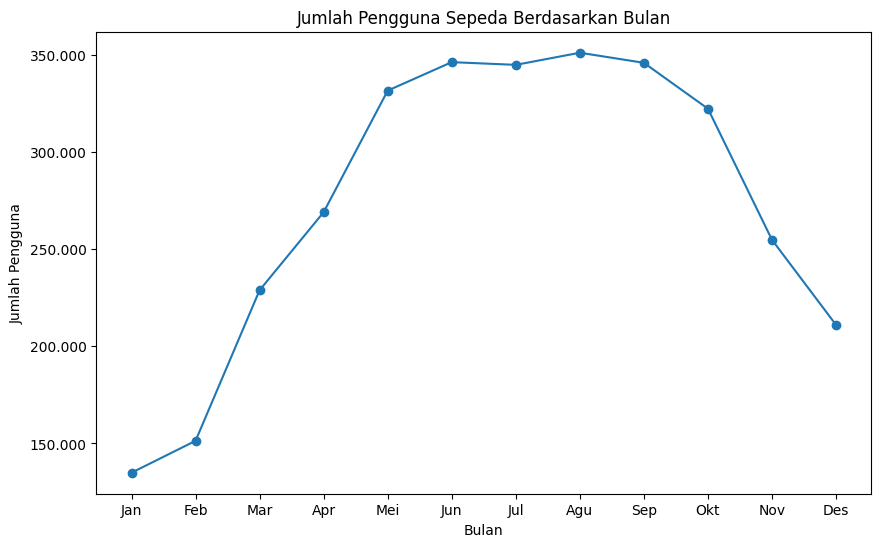

In [ ]:
# Menampilkan sebaran pengguna berdasarkan bulan
total_per_bulan = df.groupby('mnth')['cnt'].sum()

plt.figure(figsize=(10, 6))
plt.plot(total_per_bulan, marker='o')
plt.title('Jumlah Pengguna Sepeda Berdasarkan Bulan')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Pengguna')

plt.xticks(
    ticks=range(1, 13),
    labels=['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']
)
formatter = plt.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.'))
plt.gca().yaxis.set_major_formatter(formatter)
plt.show()

**Insight:**
- Penggunaan sepeda rendah pada awal tahun sekitar bulan Januari dan Februari, yang kemudian naik secara signifikan pada bulan Maret dan terus naik hingga pertengahan tahun adalah puncaknya.
- Pada bulan September tren penggunaan sepeda mulai turun perlahan dan terus turun hingga akhir tahun.
- Pola ini konsisten dengan apa yang ditunjukan oleh grafis pengguna berdasarkan musim yang mengindikasikan bahwa akhir-awal tahun musim lebih dingin dan pada pertengahan tahun lebih hangat dan nyaman untuk bersepeda.

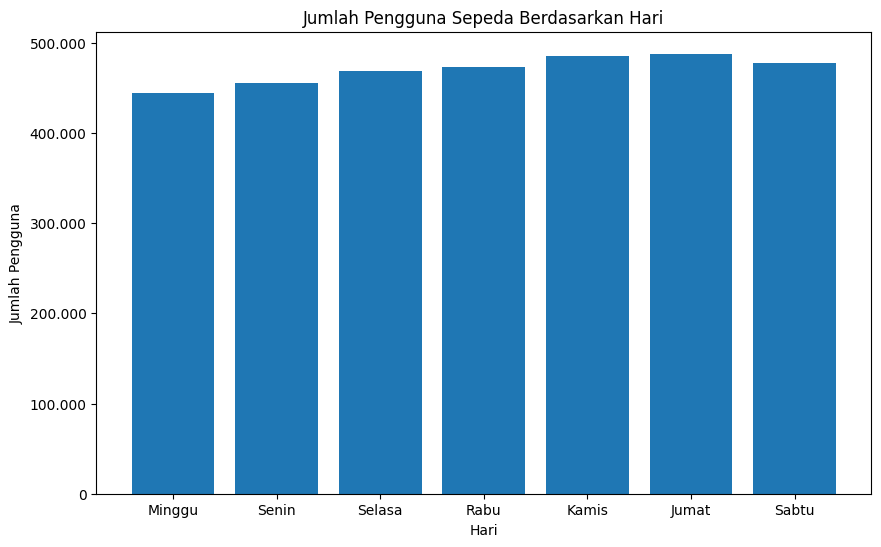

In [ ]:
# Menampilkan sebaran pengguna berdasarkan hari
total_per_hari = df.groupby('weekday')['cnt'].sum().reset_index()

plt.figure(figsize=(10, 6))
plt.bar(total_per_hari['weekday'],total_per_hari['cnt'])
plt.title('Jumlah Pengguna Sepeda Berdasarkan Hari')
plt.xlabel('Hari')
plt.ylabel('Jumlah Pengguna')

label_hari = {0:'Minggu', 1:'Senin', 2:'Selasa', 3:'Rabu', 4:'Kamis',5:'Jumat',6:'Sabtu'}
plt.xticks(ticks=total_per_hari['weekday'],labels = [label_hari[i] for i in total_per_hari['weekday']])
formatter = plt.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.'))
plt.gca().yaxis.set_major_formatter(formatter)
plt.show()

**Insight:**
- Pengguna penyewaan sepeda relatif stabil sepanjang minggu dengan naik secara bertahap dari hari senin - jumat dengan puncaknya pada hari jumat. Kemudian jumlah pengguna cenderung sedikit menurun pada akhir pekan dibandingkan hari kerja. Hal ini mengindikasikan bahwa lebih banyak pengguna memanfaatkan sepeda untuk perjalanan atau aktivitas kerja dibandingkan aktivitas sosial di akhir pekan walaupun perbedaannya tidak signifikan.


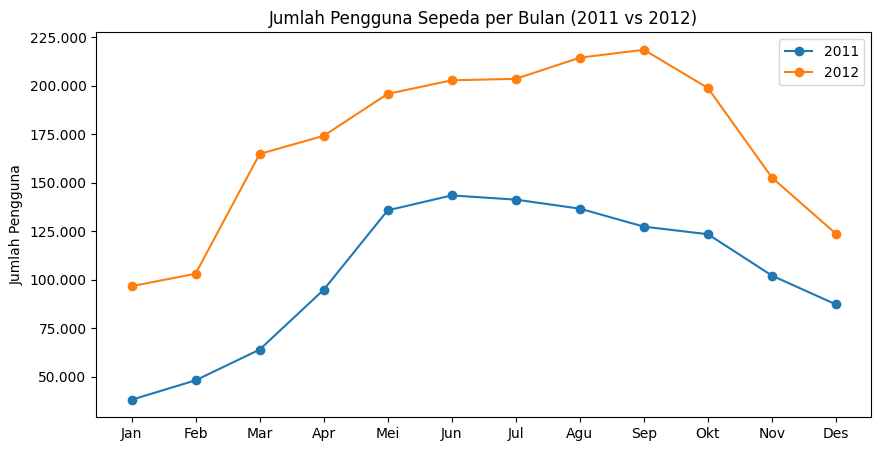

In [ ]:
# Menampilkan perbandingan jumlah pengguna sepeda pada tahun 2011 dengan 2012 berdasarkan bulan
df_2011 = df[df['yr'] == 0]
df_2012 = df[df['yr'] == 1]

total_per_bulan_2011 = df_2011.groupby('mnth')['cnt'].sum()
total_per_bulan_2012 = df_2012.groupby('mnth')['cnt'].sum()

plt.figure(figsize=(10,5))
plt.plot(total_per_bulan_2011.index, total_per_bulan_2011.values, label='2011', marker='o')
plt.plot(total_per_bulan_2012.index, total_per_bulan_2012.values, label='2012', marker='o')
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des'])
plt.ylabel('Jumlah Pengguna')
plt.gca().yaxis.set_major_formatter(formatter)
plt.title('Jumlah Pengguna Sepeda per Bulan (2011 vs 2012)')
plt.legend()
plt.show()

**Insight:**
- Secara keseluruhan, tahun 2012 memiliki jumlah pengguna yang hampir 2 kali lipat pada setiap bulan dibandingkan tahun 2011. Hal ini menunjukkan adanya kenaikan popularitas dalam sistem penyewaan sepeda di Amerika Serikat yang kemungkinan disebabkan promosi atau peningkatan kesadaran masyarakat terhadap kesehatan, lingkungan, dan lalu lintas.
- Terdapat pola musiman yang sama dalam 2 tahun yaitu peningkatan pada awal menuju pertengahan tahun, kemudian turun ketika menuju akhir tahun. Puncak penggunaan juga sama pada pertengahan tahun, sedangkan rendah pada awal dan akhir tahun. Pola ini mengindikasikan bahwa musim menjadi memang menjadi salah satu faktor utama dalam perilaku pengguna dalam menyewa sepeda.

### Pertanyaan 2: Bagaimana kondisi cuaca berpengaruh terhadap jumlah pengguna penyewaan sepeda?

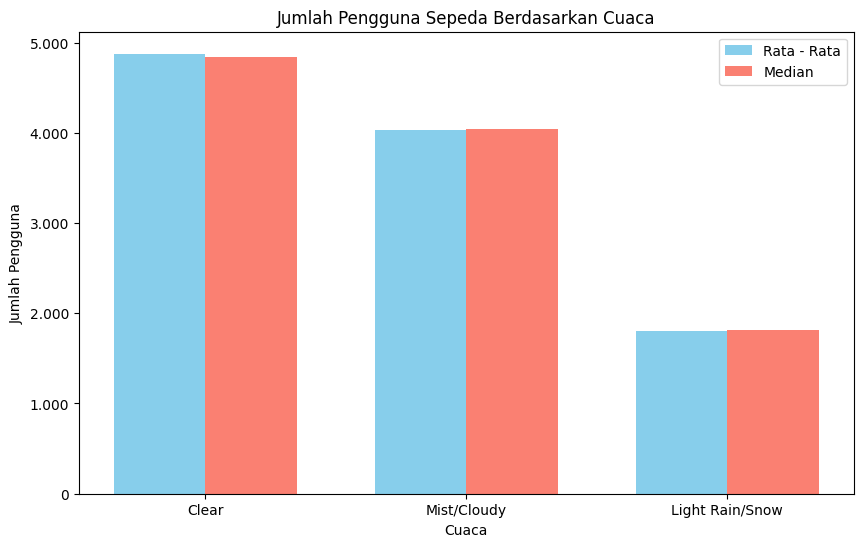



        weathersit         mean  median  count
0            Clear  4876.786177  4844.0    463
1      Mist/Cloudy  4035.862348  4040.0    247
2  Light Rain/Snow  1803.285714  1817.0     21


In [ ]:
# Menampilkan sebaran pengguna berdasarkan cuaca
total_per_cuaca = df.groupby('weathersit')['cnt'].agg(['mean','median','count']).reset_index()

plt.figure(figsize=(10, 6))
bar_width = 0.35

x=[0,1,2]
plt.bar([i - bar_width/2 for i in x],total_per_cuaca['mean'],width=bar_width,label='Rata - Rata', color = 'skyblue')
plt.bar([i + bar_width/2 for i in x],total_per_cuaca['median'],width=bar_width,label='Median', color = 'salmon')
plt.title('Jumlah Pengguna Sepeda Berdasarkan Cuaca')
plt.xlabel('Cuaca')
plt.ylabel('Jumlah Pengguna')

plt.xticks(x, ['Clear', 'Mist/Cloudy', 'Light Rain/Snow',])
formatter = plt.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.'))
plt.gca().yaxis.set_major_formatter(formatter)
plt.legend()
plt.show()

print('\n')
print('='*113)
tabel_per_cuaca = total_per_cuaca.copy()
tabel_per_cuaca['weathersit']=['Clear','Mist/Cloudy','Light Rain/Snow']
print(tabel_per_cuaca)
print('='*113)

**Insight:**
- Pada saat cuaca cerah rata - rata pengguna harian sekitar 4876 pengguna, kemudian ketika cuaca berkabut atau berawan rata - rata pengguna harian sekitar 4035, sedangkan ketika cuaca turun hujan atau salju ringan rata - rata  pengguna harian hanya sekitar 1803. Hal ini dengan catatan bahwa frekuensi sebaran cuaca tidak seimbang yang mengakibatkan kemungkinan adanya bias karena kurangnya sampel pada cuaca turun hujan atau salju ringan. Walaupun sudah menggunakan median yang lebih stabil/tahan terhadap outlier hasilnya tidak berbeda jauh dengan rata - rata.

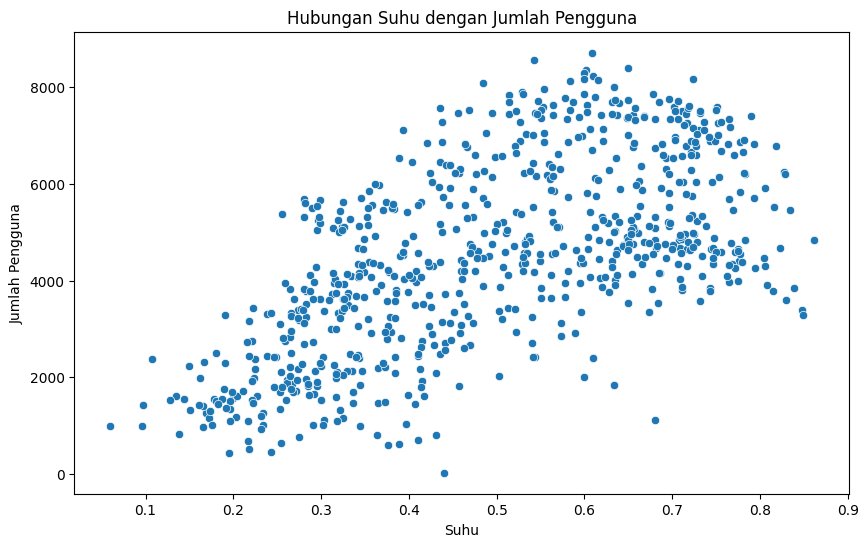


Koefisien korelasi: 0.63


In [ ]:
# Menampilkan hubungan suhu dengan total pengguna
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='temp', y='cnt')
plt.title('Hubungan Suhu dengan Jumlah Pengguna')
plt.xlabel('Suhu')
plt.ylabel('Jumlah Pengguna')
plt.show()

corr = np.corrcoef(df['temp'], df['cnt'])[0, 1].round(2)
print(f"\nKoefisien korelasi: {corr}")

**Insight:**
- Didapatkan koefisien korelasi sebesar 0.63 yang berarti ada hubungan positif yang cukup kuat antara suhu dan jumlah pengguna. Hal ini menunjukkan jika suhu semakin naik maka semakin banyak orang yang menggunakan sepeda.
- Dilihat dari sebarannya, untuk suhu rendah (< 0.3) jumlah pengguna juga rendah. Pada suhu sedang (0.3 - 0.7) jumlah pengguna meningkat secara konsisten. Sedangkan pada suhu tinggi (> 0.7) beberapa titik mulai menurun yang kemungkinan outlier atau cuaca yang terlalu panas.

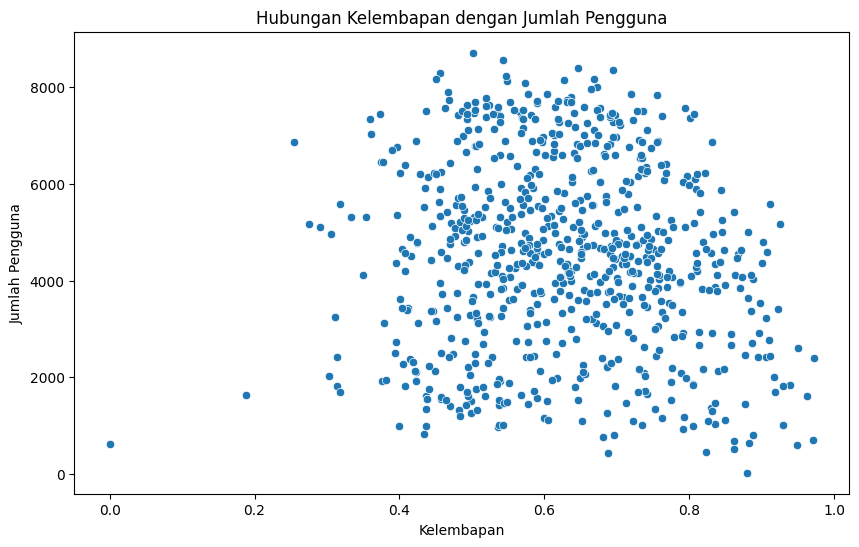


Koefisien korelasi: -0.1


In [ ]:
# Menampilkan hubungan kelembapan dengan total pengguna
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='hum', y='cnt')
plt.title('Hubungan Kelembapan dengan Jumlah Pengguna')
plt.xlabel('Kelembapan')
plt.ylabel('Jumlah Pengguna')
plt.show()

corr = np.corrcoef(df['hum'], df['cnt'])[0, 1].round(2)
print(f"\nKoefisien korelasi: {corr}")

**Insight:**
- Didapatkan koefisien korelasi sebesar -0.1 yang berarti hampir tidak ada hubungan antara kelembapan dan jumlah pengguna. Hal ini menunjukkan perubahan kelembapan tidak terlalu mempengaruhi jumlah penggunaan sepeda.
- Dilihat dari sebarannya, titik - titik tersebar secara merata pada rentang 0-1. Kemudian tidak ada tren yang jelas, hal ini menandakan pengguna masih bersepeda meski pada kelembapan tinggi maupun rendah.

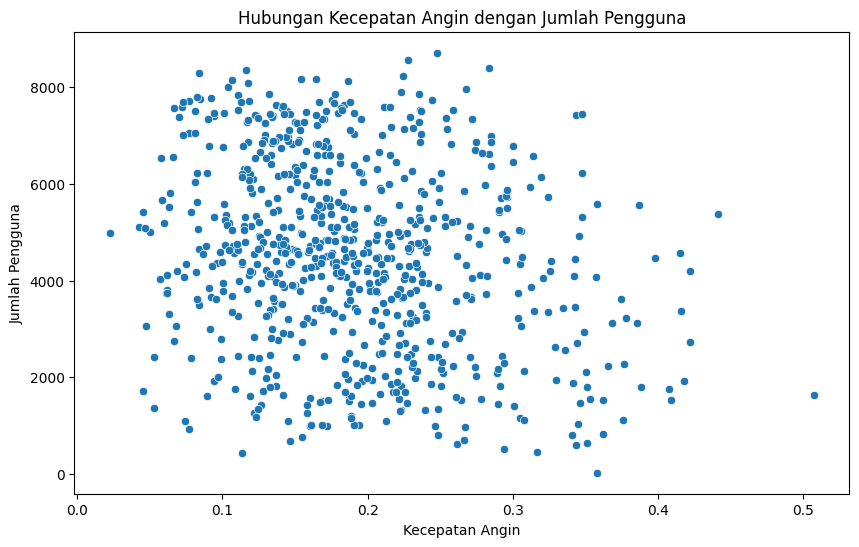


Koefisien korelasi: -0.23


In [ ]:
# Menampilkan hubungan kecepatan angin dengan total pengguna
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='windspeed', y='cnt')
plt.title('Hubungan Kecepatan Angin dengan Jumlah Pengguna')
plt.xlabel('Kecepatan Angin')
plt.ylabel('Jumlah Pengguna')
plt.show()

corr = np.corrcoef(df['windspeed'], df['cnt'])[0, 1].round(2)
print(f"\nKoefisien korelasi: {corr}")

**Insight:**
- Didapatkan koefisien korelasi sebesar -0.23 yang berarti terdapat hubungan negatif antara kecepatan angin dan jumlah pengguna walaupun lemah. Hal ini menunjukkan perubahan kecepatan angin yang semakin tinggi maka jumlah penggunaan sepeda cenderung menurun.
- Dilihat dari sebarannya, titik - titik pada kecepatan angin rendah (< 0.2) jumlah penggunaan sepeda bervariasi dari rendah hingga tinggi. Kemudian pada kecepatan angin yang lebih tinggi (> 0.3) terlihat jumlah pengguna sepeda cenderung menurun walaupun tidak signifikan tetapi masih terlihat adanya tren menurun.

### Pertanyaan 3: Bagaimana perbedaan perilaku antara pengguna casual dan registered?

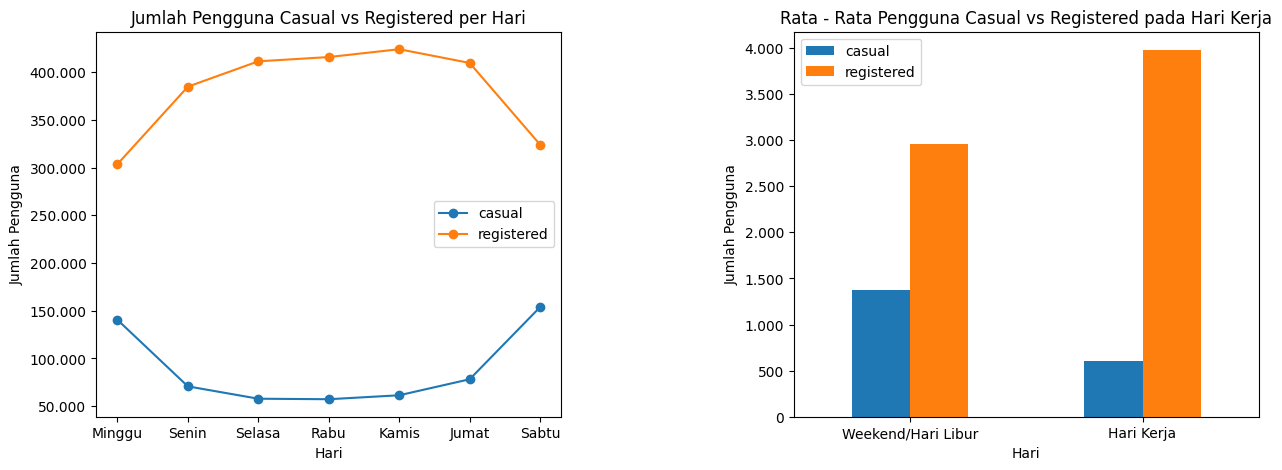

In [ ]:
# Menampilkan perbandingan perilaku pengguna berdasarkan hari
pengguna_per_hari = df.groupby('weekday')[['casual','registered']].sum()
pengguna_per_hari_kerja = df.groupby('workingday')[['casual','registered']].mean()

fig, axes = plt.subplots(1, 2, figsize=(15, 5),gridspec_kw={'wspace': 0.5})
pengguna_per_hari.plot(ax = axes[0],marker='o')
axes[0].set_xticks([0,1,2,3,4,5,6], ['Minggu','Senin','Selasa','Rabu','Kamis','Jumat','Sabtu'], rotation=0)
axes[0].set_title("Jumlah Pengguna Casual vs Registered per Hari")
axes[0].set_xlabel("Hari")
axes[0].set_ylabel("Jumlah Pengguna")
axes[0].yaxis.set_major_formatter(formatter)

pengguna_per_hari_kerja.plot(kind='bar', ax = axes[1])
plt.xticks([0,1], ['Weekend/Hari Libur', 'Hari Kerja'], rotation=0)
plt.xlabel('Hari')
plt.ylabel('Jumlah Pengguna')
plt.title('Rata - Rata Pengguna Casual vs Registered pada Hari Kerja')
plt.gca().yaxis.set_major_formatter(formatter)

plt.show()

**Insight:**
- Pada visualisasi pertama, terlihat adanya perbedaan pola perilaku antara pengguna casual dengan pengguna registered berdasarkan hari penyewaan. Jumlah pengguna casual cenderung mengalami peningkatan pada hari sabtu dan minggu, sedangkan hari senin sampai jumat jumlahnya lebih rendah dan cenderung stabil. Sebaliknya, pengguna registered menunjukkan pola yang berbeda, di mana jumlah pengguna cenderung lebih tinggi pada hari senin sampai jumat dan mengalami penurunan pada hari sabtu dan minggu.
- Pada visualisasi kedua, terlihat bahwa  rata - rata pengguna casual lebih tinggi pada akhir pekan atau hari libur dibandingkan saat hari kerja. Sebaliknya, rata - rata pengguna registered lebih tinggi saat hari kerja dibandingkan saat akhir pekan atau hari libur.

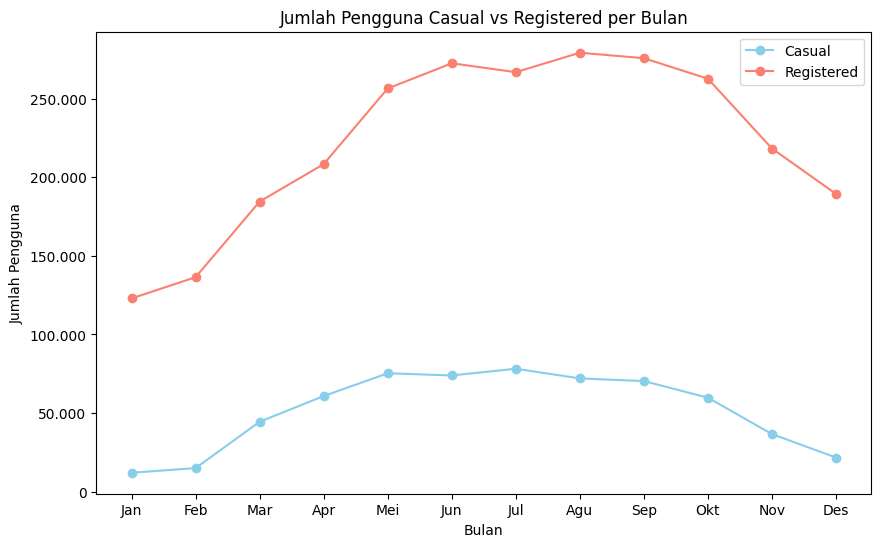

In [ ]:
# Menampilkan perbandingan perilaku pengguna berdasarkan bulan
pengguna_per_bulan = df.groupby('mnth')[['casual','registered']].sum()

plt.figure(figsize=(10, 6))
plt.plot(pengguna_per_bulan['casual'],marker='o', label = 'Casual', color = 'skyblue')
plt.plot(pengguna_per_bulan['registered'],marker='o', label = 'Registered', color = 'salmon')
plt.legend()

plt.title("Jumlah Pengguna Casual vs Registered per Bulan")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Pengguna")
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des'])
plt.gca().yaxis.set_major_formatter(formatter)
plt.show()

**Insight:**
- Pada hasil visualisasi dapat dilihat bahwa kedua jenis pengguna memiliki pola perilaku yang serupa, yaitu mengalami kenaikan menuju pertengahan tahun kemudian turun pada akhir tahun yang kemungkinan besar dipengaruhi kondisi musim atau lingkungan.

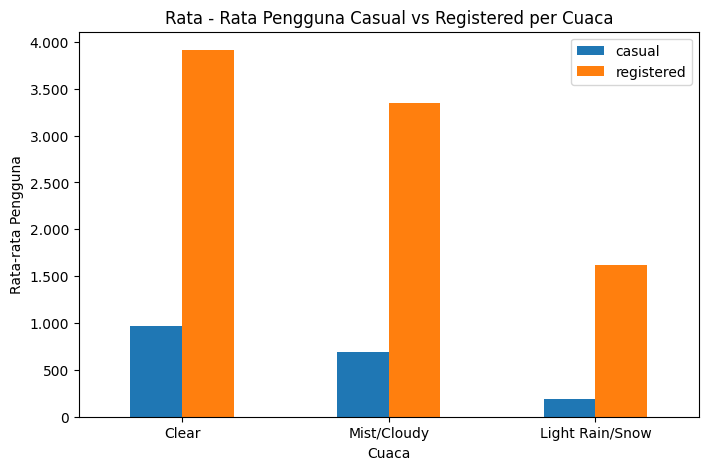

In [ ]:
# Menampilkan perbandingan perilaku pengguna berdasarkan cuaca
pengguna_per_cuaca = df.groupby('weathersit')[['casual','registered']].mean()
pengguna_per_cuaca.plot(kind='bar', figsize=(8,5))
plt.xticks([0,1,2], ['Clear','Mist/Cloudy','Light Rain/Snow'], rotation=0)
plt.ylabel('Rata-rata Pengguna')
plt.xlabel('Cuaca')
plt.title('Rata - Rata Pengguna Casual vs Registered per Cuaca')
plt.gca().yaxis.set_major_formatter(formatter)
plt.show()

**Insight:**
- Berdasarkan hasil visualisasi, baik pengguna casual maupun pengguna registered menunjukkan pola yang serupa terhadap kondisi cuaca. Jumlah pengguna cenderung paling tinggi pada kondisi cuaca cerah, kemudian menurun pada kondisi berkabut atau berawan, dan kembali menurun pada kondisi hujan atau salju ringan. Namun, penurunan pada pengguna casual terlihat lebih signifikan dibandingkan pengguna registered, yang menunjukkan bahwa pengguna casual lebih sensitif terhadap kondisi cuaca, sementara pengguna registered cenderung tetap menggunakan layanan meskipun kondisi cuaca kurang mendukung.

## Analisis Lanjutan : Analisis Binning
Analisis binning adalah metode mengelompokkan data numerik kontinu ke dalam interval atau kategori tertentu.

Dalam studi kasus ini, analisis binning digunakan untuk:
- Mengelompokkan data cuaca numerik menjadi kategori yang dapat dibandingkan.
- Menyederhanakan analisis jumlah pengguna sepeda berdasarkan kondisi lingkungan.
- Memberikan dasar visualisasi dan insight yang jelas untuk strategi operasional.


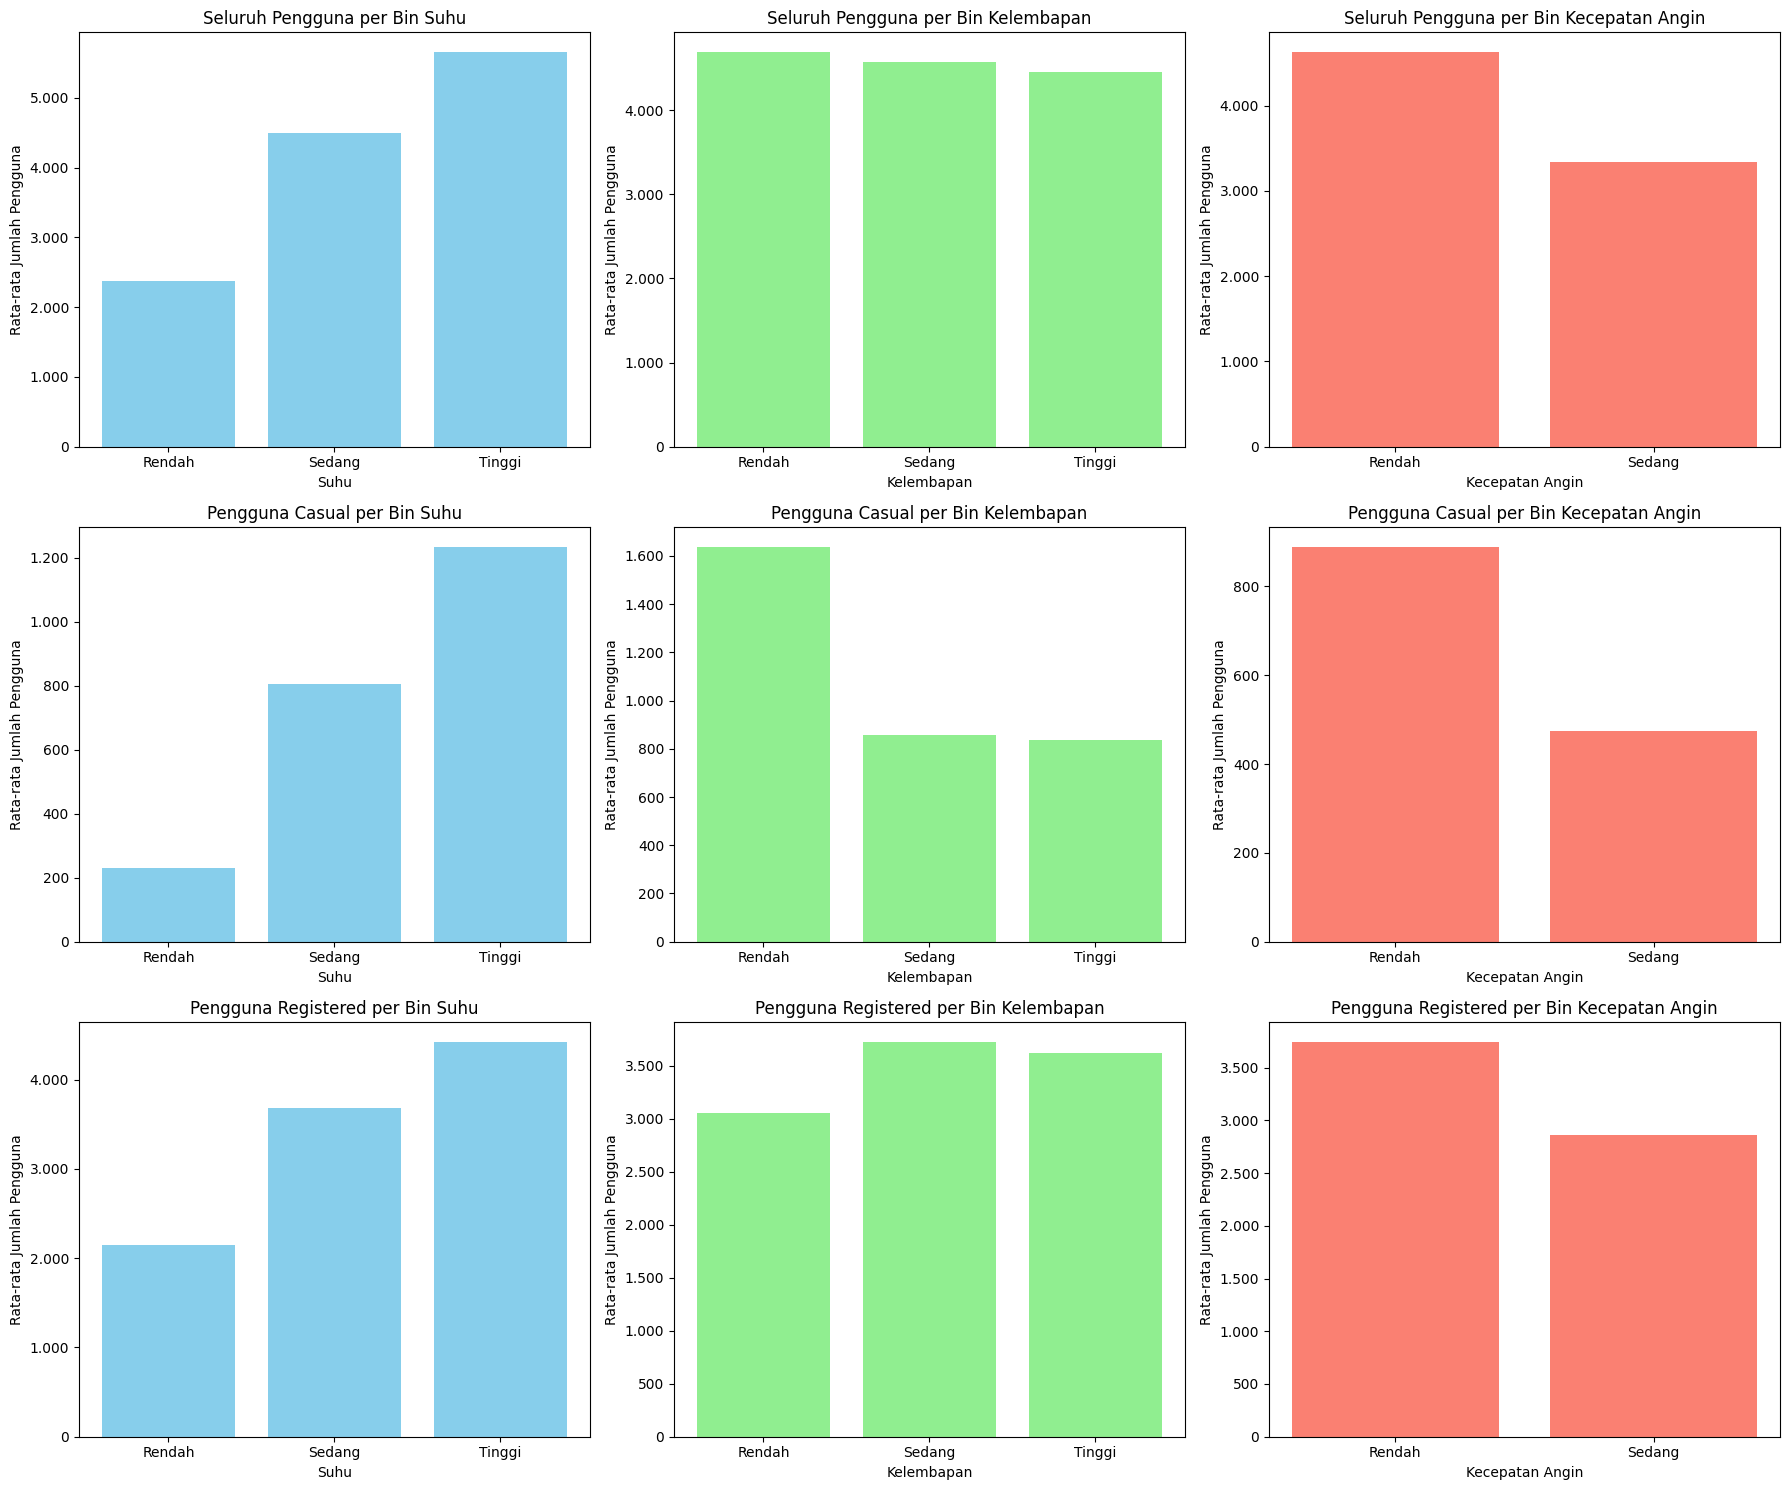

In [ ]:
# Membuat bin untuk suhu
df['temp_bin'] = pd.cut(df['temp'], bins=[0, 0.3, 0.6, 1], labels=['Rendah','Sedang','Tinggi'])
# Membuat bin untuk kelembapan
df['hum_bin'] = pd.cut(df['hum'], bins=[0, 0.3, 0.6, 1], labels=['Rendah','Sedang','Tinggi'])
# Membuat bin untuk kecepatan angin
df['windspeed_bin'] = pd.cut(df['windspeed'], bins=[0, 0.3, 0.6, 1], labels=['Rendah','Sedang','Tinggi'])

# Daftar tipe pengguna dan labelnya
user_types = ['cnt', 'casual', 'registered']
user_labels = ['Seluruh Pengguna', 'Pengguna Casual', 'Pengguna Registered']

# Daftar bin variabel dan labelnya
bins_cols = ['temp_bin', 'hum_bin', 'windspeed_bin']
bins_labels = ['Suhu', 'Kelembapan', 'Kecepatan Angin']
colors = ['skyblue', 'lightgreen', 'salmon']

# Pembuatan Plot
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
for i, user in enumerate(user_types):
    for j, col in enumerate(bins_cols):
        # Hitung rata-rata per bin
        agg = df.groupby(col, observed=True)[user].mean().reset_index()

        # Plot
        axes[i, j].bar(agg[col], agg[user], color=colors[j])
        axes[i, j].set_title(f"{user_labels[i]} per Bin {bins_labels[j]}")
        axes[i, j].set_xlabel(bins_labels[j])
        axes[i, j].set_ylabel("Rata-rata Jumlah Pengguna")
        axes[i, j].yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

**Insight:**
- Suhu: Rata-rata jumlah pengguna meningkat dari kategori rendah ke tinggi untuk semua tipe pengguna. Untuk seluruh pengguna, kenaikan terlihat jelas seiring naiknya suhu, mencerminkan tren umum penggunaan sepeda. Pengguna casual mengikuti pola yang sama namun jumlahnya lebih kecil, menunjukkan aktivitas casual lebih sensitif terhadap suhu rendah. Sementara itu, pengguna registered memiliki jumlah terbesar di semua kategori suhu dan tren kenaikan paling konsisten, menunjukkan stabilitas tinggi meskipun suhu berubah.

- Kelembapan: Perilaku tiap tipe pengguna berbeda. Pengguna casual mengalami penurunan jumlah saat kelembapan naik, menandakan aktivitas casual menurun pada kondisi lembap. Sebaliknya, pengguna registered tetap stabil atau sedikit meningkat ketika kelembapan tinggi, menunjukkan toleransi lebih terhadap kelembapan. Seluruh pengguna berada di antara keduanya, mencerminkan gabungan perilaku casual dan registered.

- Kecepatan Angin: Semua tipe pengguna menampilkan penurunan rata-rata jumlah pengguna saat kecepatan angin meningkat dari rendah ke sedang. Penurunan paling tajam terlihat pada casual, sedangkan registered tetap relatif stabil dengan hanya sedikit penurunan. Seluruh pengguna menunjukkan tren moderat, mencerminkan efek gabungan casual dan registered. Hal ini menunjukkan bahwa angin memengaruhi aktivitas casual lebih kuat dibanding registered.



## Conclusion

**Conclution pertanyaan 1**

Berdasarkan hasil analisis, penggunaan sepeda menunjukkan pola musiman yang kuat, di mana jumlah penyewaan meningkat dari awal tahun dan mencapai puncaknya pada pertengahan tahun, kemudian menurun kembali pada akhir tahun. Pola ini mengindikasikan bahwa faktor waktu, khususnya bulan, memiliki pengaruh signifikan terhadap tingkat penggunaan sepeda. Selain itu, berdasarkan hari, penggunaan cenderung lebih tinggi pada hari kerja dibandingkan akhir pekan, yang menunjukkan bahwa sebagian besar pengguna memanfaatkan sepeda sebagai sarana transportasi rutin. Dengan demikian, perusahaan dapat menerapkan strategi operasional dengan meningkatkan ketersediaan armada dan layanan pada periode high season serta hari kerja, serta melakukan efisiensi operasional dan promosi pada periode low season untuk menjaga stabilitas permintaan.

**Conclution pertanyaan 2**

Analisis faktor cuaca menunjukkan bahwa suhu, kelembapan, dan kecepatan angin mempengaruhi jumlah pengguna sepeda. Suhu hangat meningkatkan penggunaan sepeda, kelembapan tinggi sedikit menurunkan jumlah pengguna, dan angin kencang cenderung menurunkan aktivitas bersepeda. Oleh karena itu, perusahaan dapat memaksimalkan operasional dan penempatan sepeda pada kondisi cuaca baik, serta menerapkan strategi promosi atau insentif khusus pada kondisi cuaca buruk untuk mempertahankan tingkat penggunaan.

**Conclusion pertanyaan 3**

Analisis menunjukkan adanya perbedaan pola perilaku yang jelas antara pengguna casual dan pengguna registered. Pengguna casual cenderung lebih banyak menggunakan sepeda pada akhir pekan dan sangat dipengaruhi oleh faktor musiman serta kondisi cuaca, yang menunjukkan bahwa penggunaannya bersifat rekreatif. Sebaliknya, pengguna registered cenderung lebih aktif pada hari kerja dan menunjukkan pola penggunaan yang lebih stabil sepanjang waktu, yang mengindikasikan penggunaan untuk kebutuhan rutin seperti bekerja atau beraktivitas harian. Berdasarkan hal tersebut, perusahaan dapat menerapkan strategi segmentasi dengan mempertahankan pengguna registered melalui program keanggotaan atau loyalitas, serta meningkatkan pengguna casual melalui promosi berbasis waktu seperti akhir pekan dan musim dengan kondisi yang mendukung.